In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("loan_approval_data.csv")

In [4]:
df.describe
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handle missing values

In [6]:
categorical_data = df.select_dtypes(include=["object"]).columns
numerical_data = df.select_dtypes(include=["float64","int64"]).columns

In [7]:
categorical_data

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [8]:
numerical_data

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [9]:
## Simpple imputer fill the all missing values with proper strategy
num_imp = SimpleImputer(strategy="mean")
df[numerical_data] = num_imp.fit_transform(df[numerical_data])

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_data] = cat_imp.fit_transform(df[categorical_data])


# EDA

In [10]:
categorical_data

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

([<matplotlib.patches.Wedge at 0x1daff6c1a90>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'No'),
  Text(0.6521428261765839, -0.8858384357581341, 'Yes')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

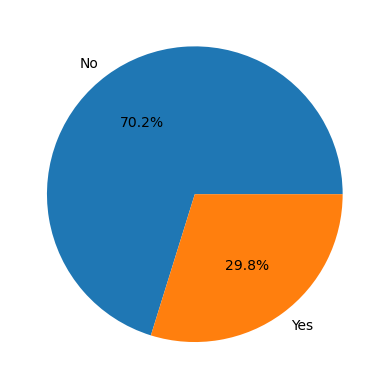

In [11]:
## Analizing the all category that impacts output 
class_cnt = df["Loan_Approved"].value_counts()
plt.pie(class_cnt,labels=["No","Yes"],autopct="%1.1f%%")



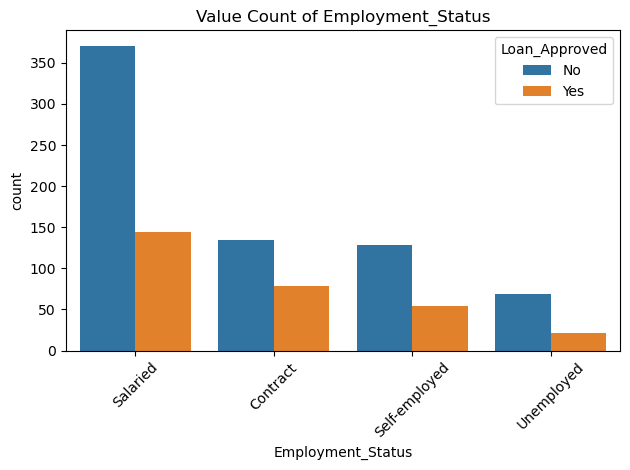

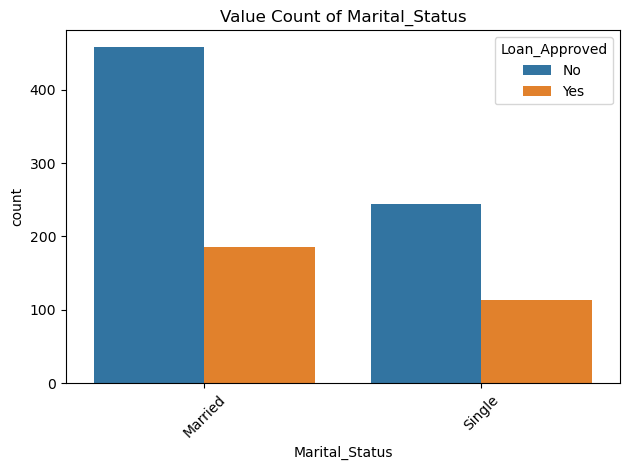

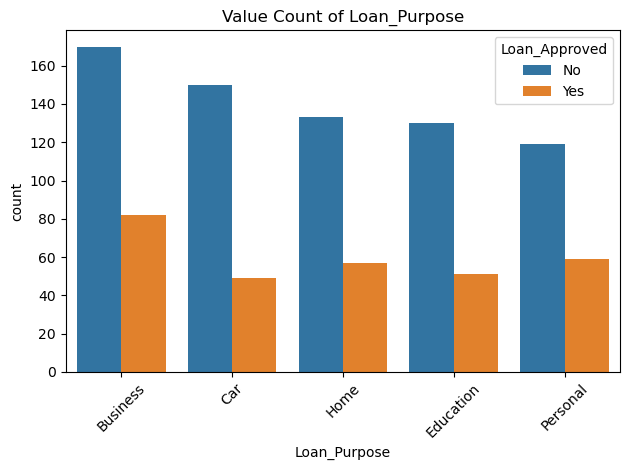

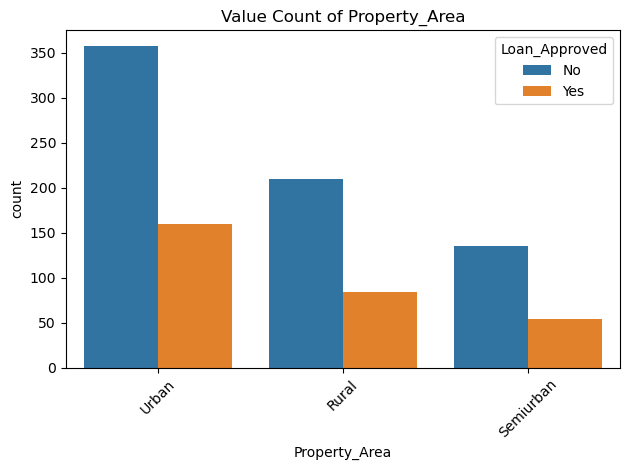

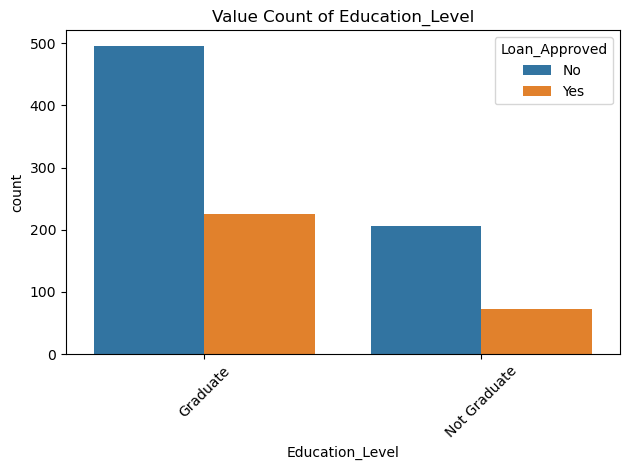

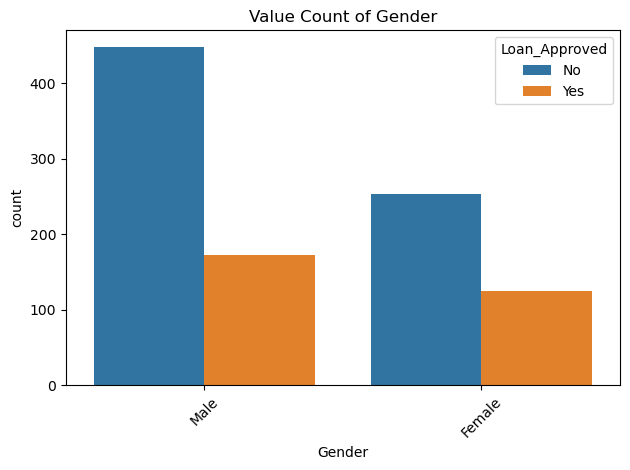

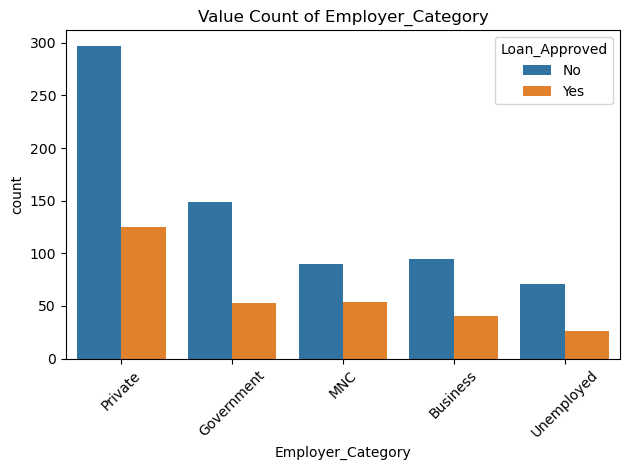

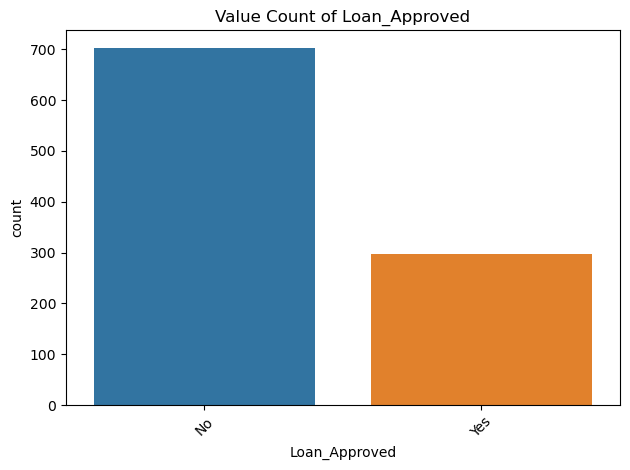

In [15]:
for col in categorical_data:
    plt.figure()
    
    order = df[col].value_counts().index
    sns.countplot(x=col,data=df,order=order,hue="Loan_Approved")
    
    plt.title(f"Value Count of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

IndexError: index 9 is out of bounds for axis 0 with size 9

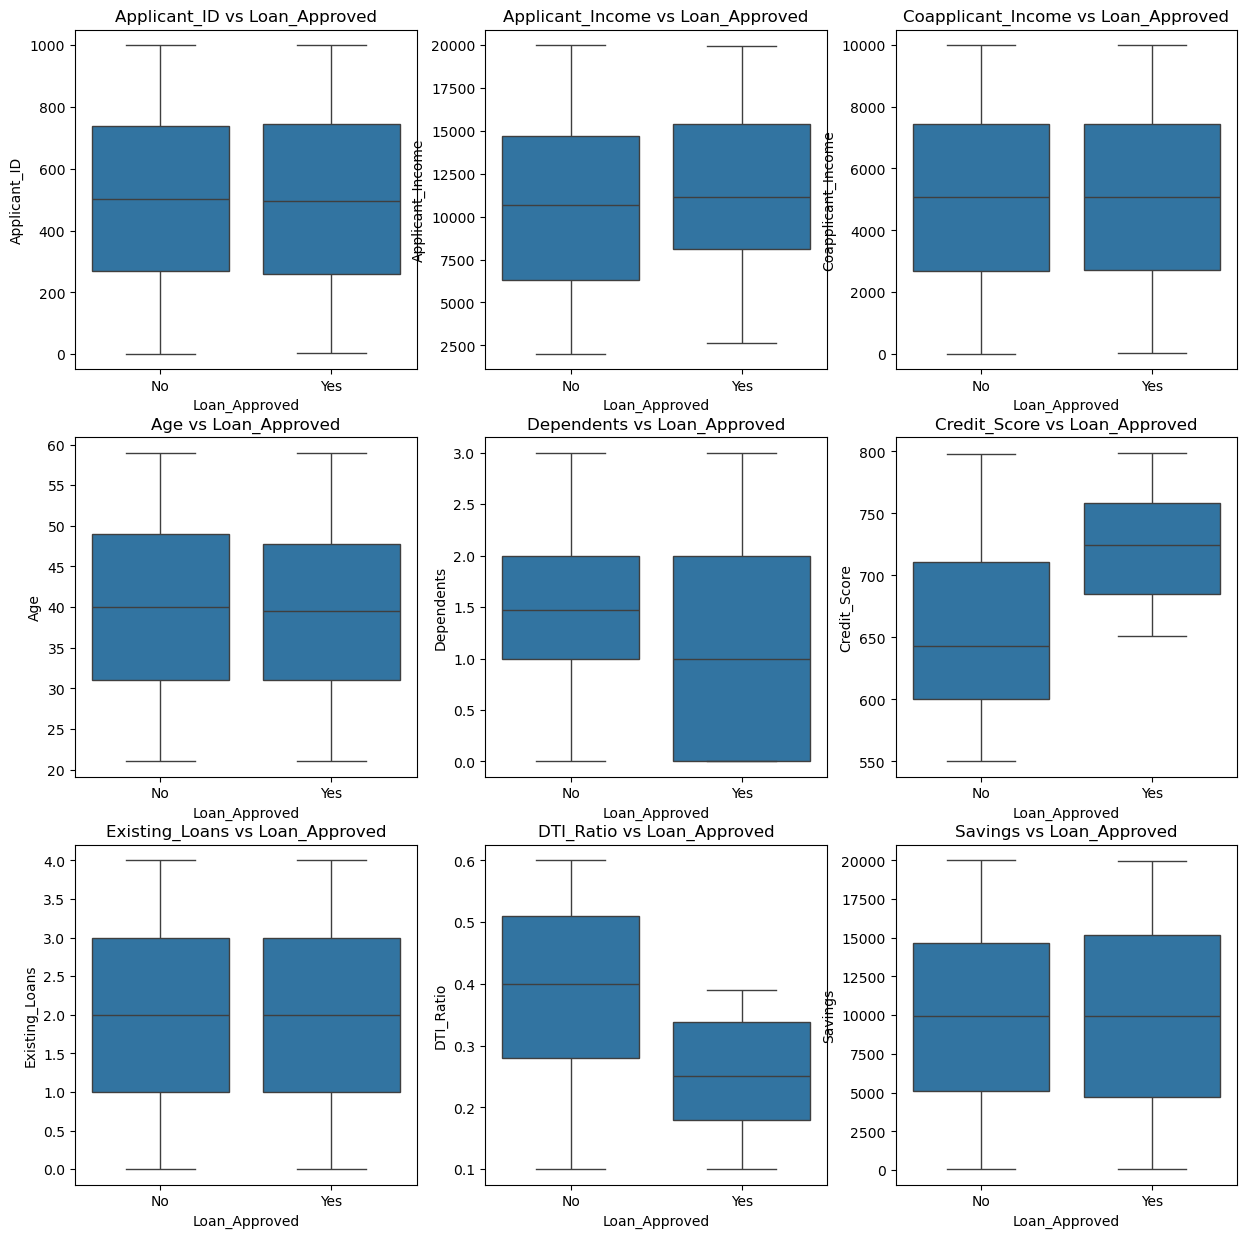

In [13]:
## chrcking the outliers
fig , axes = plt.subplots(3,3,figsize=(15,15))
axes = axes.flatten()
for i,col in enumerate(numerical_data):
    sns.boxplot(ax=axes[i],y=col , x="Loan_Approved",data=df)
    axes[i].set_title(f"{col} vs Loan_Approved")
    

plt.tight_layout()

In [ ]:
numerical_data

<Axes: xlabel='Credit_Score', ylabel='Count'>

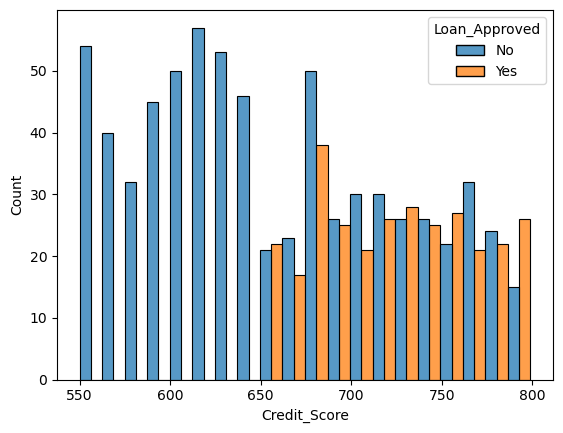

In [16]:
## Relation between credit score and Loan Approved 
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20
)

## Important-insights = credit_score > 650 loan_approved but not approved below 650

<Axes: xlabel='Applicant_Income', ylabel='Count'>

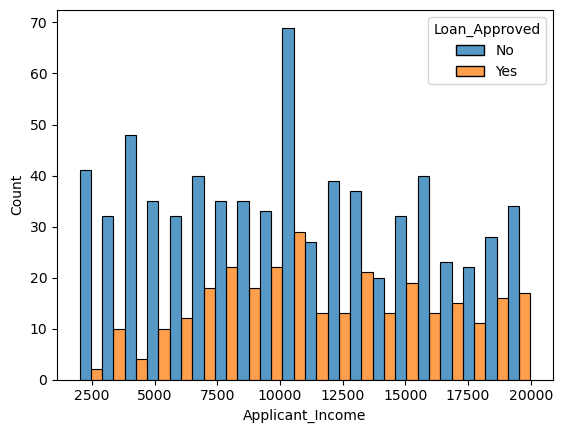

In [17]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20
)

## possibility for loan approval increases to mid to high salary range

In [18]:
df = df.drop("Applicant_ID",axis=1)

# Encoding our data 

In [36]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   int64  
 16  Gender 

In [37]:
## label Encoding
le = LabelEncoder()
df["Education_Level"]= le.fit_transform(df["Education_Level"])
df["Loan_Approved"]= le.fit_transform(df["Loan_Approved"])

## OneHotEncoding 
cols = ["Employment_Status","Loan_Purpose","Property_Area","Gender","Employer_Category","Marital_Status"]
ohe = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
encoded_data = ohe.fit_transform(df[cols])
## convert encoded data to DataFrame
encoded_df = pd.DataFrame(encoded_data,columns=ohe.get_feature_names_out(cols),index=df.index)
## Append with main data
df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [31]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Marital_Status_Single
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0


In [40]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

(1000, 28)

# Correlation Heatmap

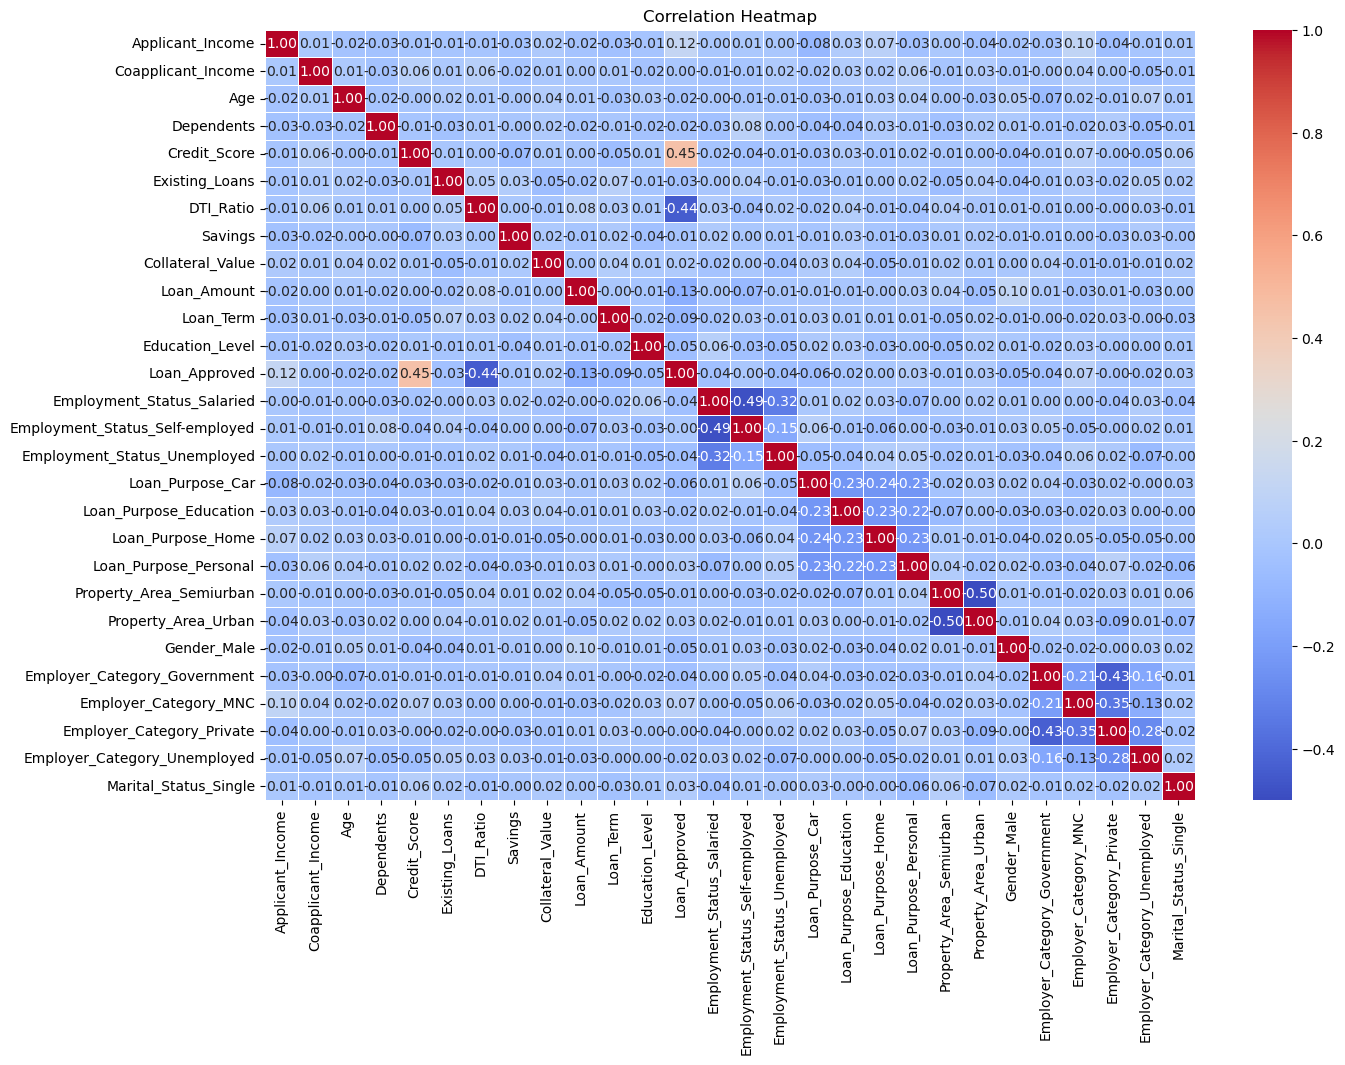

In [50]:
## FIndinf cor relation between wvery feture with the output feature
numeric_feature = df.select_dtypes(include="number")
numeric_feature.corr()["Loan_Approved"].sort_values(ascending=False)
corr_matrix = numeric_feature.corr()
# Plot heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, 
            annot=True,        # show values
            cmap="coolwarm",   # color theme
            fmt=".2f",         # 2 decimal places
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

# Feature Scaling

In [51]:
X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [53]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Marital_Status_Single
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [56]:
## Scalling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -8.59726954e-01, -3.07231582e-01, -7.15742506e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -8.59726954e-01, -3.07231582e-01, -7.15742506e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
         1.16316000e+00, -3.07231582e-01, -7.15742506e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
         1.16316000e+00, -3.07231582e-01,  1.39715050e+00],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -8.59726954e-01, -3.07231582e-01, -7.15742506e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -8.59726954e-01, -3.07231582e-01,  1.39715050e+00]],
      shape=(800, 27))

# Model Training & Evaluation

In [64]:
## Logistic Regresssion 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , f1_score , recall_score

lg_model = LogisticRegression()
lg_model.fit(X_train_scaled , y_train)
## predict the output
y_pred = lg_model.predict(X_test_scaled)

print("precision score:",precision_score(y_test,y_pred))
print("recall score:",recall_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("Confusion_matrix:",confusion_matrix(y_test,y_pred))


precision score: 0.7833333333333333
recall score: 0.7704918032786885
f1 score: 0.7768595041322314
accuracy score: 0.865
Confusion_matrix: [[126  13]
 [ 14  47]]


In [70]:
## KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

print("precision score:",precision_score(y_test,y_pred))
print("recall score:",recall_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("Confusion_matrix:",confusion_matrix(y_test,y_pred))

precision score: 0.6086956521739131
recall score: 0.45901639344262296
f1 score: 0.5233644859813084
accuracy score: 0.745
Confusion_matrix: [[121  18]
 [ 33  28]]


In [71]:
## Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled , y_train)

y_pred = nb_model.predict(X_test_scaled)

print("precision score:",precision_score(y_test,y_pred))
print("recall score:",recall_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("Confusion_matrix:",confusion_matrix(y_test,y_pred))

precision score: 0.8035714285714286
recall score: 0.7377049180327869
f1 score: 0.7692307692307693
accuracy score: 0.865
Confusion_matrix: [[128  11]
 [ 16  45]]


# GaussianNB is the most accurate based on the precision Score & confusion Matrix 